# 60 Minutes to Pyomo: An Energy Storage Model Predictive Control Example

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 29 rewritten and 2 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

In [2]:
import pandas as pd
import pyomo.environ as pyo
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pyomo.environ import units as u
from pyomo.util.check_units import assert_units_consistent

# Pyomo's unit library has MW and MWh but no money, so declare a currency.
u.load_definitions_from_strings(["USD = [currency]"])

# Three entries of the Okabe-Ito palette that figures/dowling.mplstyle cycles.
# Almost every plot below takes its colour from that cycle automatically and
# names no colour at all. These three are named because the same three series
# appear in the canonical handout figure rendered by
# figures/plots/battery-arbitrage.py, and the live cells should agree with it.
BLUE = "#0072B2"  # energy price, and the state of charge
VERMILLION = "#D55E00"  # charging   (buying from the market)
BLUISH_GREEN = "#009E73"  # discharging (selling to the market)

## Problem Setup

### Background

In many regions of the world, including the US, electricity generation is scheduled through wholesale electricity markets. Individual generators (resources) transmit information about their operating costs and constraints to the market via a bid. The market operator then solves an optimization problem (e.g., the unit commitment problem) to minimize the total electricity generator cost. The market operator decides which generators to dispatch during each hour to satisfy the forecasted demand while honoring limitations for each generator (e.g., maximum ramp rate, the required time for start-up/shutdown, etc.).

![Map of the United States coloured by wholesale electricity market: the seven RTO/ISO regions (CAISO, SPP, ERCOT, MISO, PJM, NYISO and ISO-NE) cover most of the country, while much of the Southeast and the non-California West are not served by an organized market.](https://www.ferc.gov/sites/default/files/2020-06/map-overview-electric.jpg)

Read more information here:
* https://www.ferc.gov/industries-data/market-assessments/electric-power-markets
* https://www.sciencedirect.com/science/article/pii/S0306261916318487

### Pandas and Energy Prices

The CSV (comma separated value) file `Prices_DAM_ALTA2G_7_B1.csv` contains price data for a single location in California for an entire year. The prices are set every hour and have units $/MWh. We will use the package `pandas` to import and analyze the data.

In [3]:
# Load the data file
ca_data = pd.read_csv("https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/data/Prices_DAM_ALTA2G_7_B1.csv", names=["price"])

# Print the first 10 rows
ca_data.head()

,price
0,36.757
1,34.924
2,33.389
3,32.035
4,33.694


Next we can calculate summary statistics:

In [4]:
ca_data.describe()

,price
count,8760.000000
mean,32.516994
std,9.723477
min,-2.128700
25%,26.510000
50%,30.797500
75%,37.544750
max,116.340000


<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 What are 2 or 3 interesting observations from these summary statistics?
</div>

Next, let's visualize the data in a histogram:

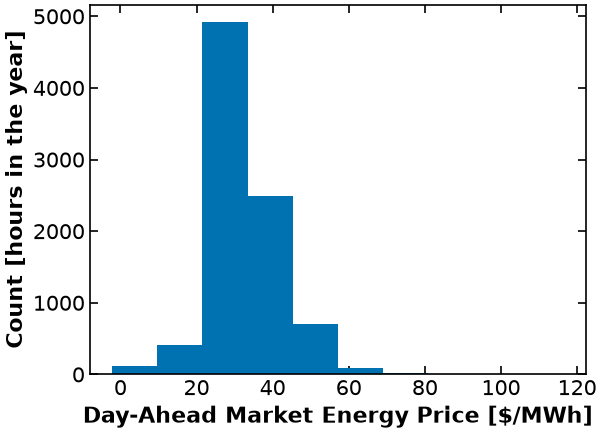

In [5]:
plt.hist(ca_data["price"], color=BLUE)
plt.xlabel("Day-Ahead Market Energy Price [$/MWh]")
plt.ylabel("Count [hours in the year]")
plt.show()

Finally, let's visualize the prices during the first full calendar week. The data are for calendar year 2015. For reference, January 1, 2015 was a Thursday.

```{note}
The canonical version of this figure is rendered once, from
[`figures/plots/dam-price-week.py`](https://github.com/ndcbe/optimization/blob/main/figures/plots/dam-price-week.py),
and is the same picture that appears in the Lecture 1 handout. The live cell below redraws it so you
can change the window; if the two ever disagree, the script is the source of truth.
```

![One calendar week of day-ahead price](https://raw.githubusercontent.com/ndcbe/optimization/main/media/figures/dam-price-week.png)


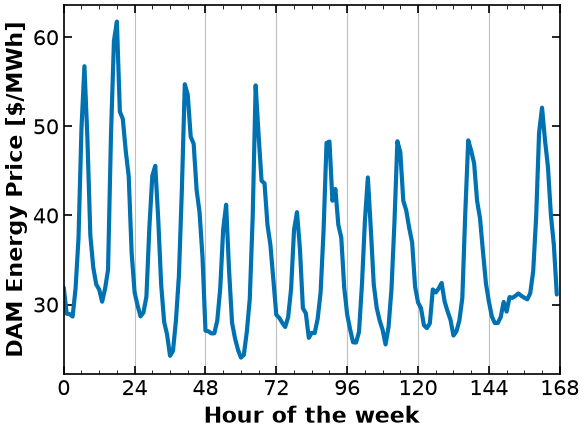

In [6]:
offset = 4  # days. January 1, 2015 was a Thursday, so +4 days lands on Monday.
number_of_days = 7
first_week = ca_data["price"].to_numpy()[
    (0 + offset) * 24 : (0 + offset + number_of_days) * 24
]

fig, ax = plt.subplots()

# Blue, matching the price panel of the canonical figure above
ax.plot(range(0, number_of_days * 24), first_week, color=BLUE, linestyle="-")

# Major ticks every 24 hours (one day), minor ticks every 6 hours
ax.xaxis.set_major_locator(MultipleLocator(24))
ax.xaxis.set_minor_locator(MultipleLocator(6))

# Light rules at the day boundaries rather than a full grid. The house style
# (figures/dowling.mplstyle) leaves axes.grid off, and the day boundaries are
# the only reference the eye needs here -- this is what the canonical script
# figures/plots/dam-price-week.py draws.
for boundary in range(24, number_of_days * 24, 24):
    ax.axvline(boundary, color="0.75", linewidth=0.8, zorder=0)

ax.set_xlim(0, number_of_days * 24)
ax.set_xlabel("Hour of the week")
ax.set_ylabel("DAM Energy Price [$/MWh]")
plt.show()

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 What are 1 or 2 interesting observations from these plots?
</div>

### Optimization Mathematical Model

*Energy (price) arbitrage* is the idea of using energy storage (e.g., a battery) to take advantage of the significant daily energy price swings. This gives rise to many analysis questions including:

*If a battery energy storage system perfectly timed its energy purchases and sales (i.e., it could perfectly forecast the market price), how much money could it make from energy arbitrage?*

We can answer this question using mathematical/computational optimization!

Let's start by drawing a picture.

![Diagram of the energy arbitrage problem. A battery installation sits below a map of the US transmission grid. Two arrows connect them: charge power c_t in megawatts flows down from the grid into the battery, and discharge power d_t in megawatts flows up from the battery to the grid. The battery itself holds energy E_t in megawatt hours.](https://raw.githubusercontent.com/ndcbe/optimization/main/media/battery.png)

#### Sets
Let's say we want to define our optimization problem over a 24 hour window. The day-ahead market sets the energy prices in 1-hour intervals. We'll define the set

$$\mathcal{T} = \{0, 1, ..., N\}$$

for time where $N = 24$ for a 24-hour planning horizon. For convenience, we'll also define $\mathcal{T}' := \mathcal{T} / \{0\}$, which is the original set $\mathcal{T}$ subtract subset $\{0\}$.


#### Variables

Next, let's identify the variables in the optimization problem:
* $E_t$, energy stored in battery at time $t$, units: MWh
* $d_t$, battery discharge power (sold to market) during time interval [t-1, t), units: MW
* $c_t$, battery charge power (purchased from the market) during time interval [t-1, t), units: MW

Notice how all of these variables are indexed by the timestep $t$. We'll write in the model $t \in \mathcal{T}'$

#### Parameters

Parameters are data that are constant during the optimization problem. Here we have:
* $\pi_t$: Energy price during time interval [t-1, t), units: \$/MWh
* $\eta$: Round trip efficiency, units: dimensionless
* $c_{max}$ Maximum charge power, units: MW
* $d_{max}$ Maximum discharge power, units: MW
* $E_{max}$ Maximum storage energy, units: MWh
* $E_{0}$ Energy in storage at time $t=0$, units: MWh
* $\Delta t = 1$ hour, Timestep for grid decisions and prices (fixed)

#### Objective and Constraints

Finally, we'll identify the objective, which is the function to improve, and the mathematical constraints. Below is the full mathematical model for the problem:

$$
\begin{align*}
    \max_{\mathbf{E},\mathbf{d},\mathbf{c}} \quad & \psi := \sum_{t \in \mathcal{T}'} \pi_{t} \Delta t (d_{t} - c_{t}) \\
\mathrm{s.t.} \quad & E_{t} = E_{t-1} + \Delta t \left( c_{t} \sqrt{\eta} - \frac{d_{t}}{\sqrt{\eta}} \right), ~~ \forall ~ t \in \mathcal{T}' \\
    & E_{0} = E_{N} \\
    & 0 \leq c_{t} \leq c_{max}, ~~\forall ~ t \in \mathcal{T}' \\
    & 0 \leq d_{t} \leq d_{max}, ~~\forall ~ t \in \mathcal{T}' \\
    & 0 \leq E_{t} \leq E_{max},  ~~\forall ~ t \in \mathcal{T}'
\end{align*}
$$

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Write on paper a 1-sentence description for each equation.
</div>

### Degree of Freedom Analysis

Before we program our model in Pyomo, it is *very important* to first perform a degree of freedom analysis. Here are the steps:
* Count the number of variables
* Count the number of equality constraints
* Degrees of freedom = number of variables subtract number of equality constraints

The degrees of freedom are the number of decision variables that can be freely manipulated by the optimizer. If there are no degrees of freedom, we often say the problem is square or it is a simulation problem.

For now, we will ignore inequality constraints and bounds. Later in the semester we will revisit degree of freedom analysis using some optimization theory concepts (e.g., active sets).

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Perform degree of freedom analysis.
</div>

## Pyomo Modeling Components

<div class="admonition danger"> 
<b>Important</b>: Do NOT implement an optimization model in Pyomo (or any other software) until you have written it on paper and performed degree of freedom analysis, as done above. Be sure to resolve any doubts, questions, or concerns while your model is still on paper. When applying optimization to a problem, a majority of the mistakes happen at the problem formulation step. So do not rush it!
</div>

### Create `ConcreteModel`

We will start by creating a concrete Pyomo model. Recall, Pyomo is an object-oriented algebraic modeling language. The line below creates an instance of the ConcreteModel class.

In [7]:
m = pyo.ConcreteModel()

For those unfamiliar with object-oriented programming, `m` is a container to define an optimization model. It includes a bunch of functionality to interface with different optimization solvers, perform diagnostics, and inspect the solution.

Pyomo also supports abstract models, but we will stick with concrete models this semester. See the Pyomo textbook for more details if you are curious.

### Sets

We start by declaring a set for time. From above, recall we want to index all of the variables and constraints over the set

$$
\mathcal{T}' = \mathcal{T} / \{0\} = \{1, ..., N\}
$$

In [8]:
# Save the number of timesteps
m.N = 24

# Define the horizon set
m.HORIZON = pyo.Set(initialize=range(1, m.N + 1))

Some Pyomo modelers prefer to use all capital names for sets; this is a personal preference.

### Variables

Next, we can declare our three variables: $E_t$, $c_t$, $d_t$

In [9]:
# Charging rate [MW]
m.c = pyo.Var(
    m.HORIZON, initialize=0.0, bounds=(0, 1), domain=pyo.NonNegativeReals, units=u.MW
)

# Discharging rate [MW]
m.d = pyo.Var(
    m.HORIZON, initialize=0.0, bounds=(0, 1), domain=pyo.NonNegativeReals, units=u.MW
)

# Energy (state-of-charge) [MWh]
m.E = pyo.Var(
    m.HORIZON, initialize=0.0, bounds=(0, 4), domain=pyo.NonNegativeReals, units=u.MWh
)

The keyword arguments for `Var` are collected below. Compiled from the
[Pyomo documentation](https://pyomo.readthedocs.io/en/stable/explanation/modeling/math_programming/variables.html)
and checked line by line against the `Var` constructor in Pyomo 6.10.1, the version this notebook runs on.

| Keyword | What it controls | Accepted values |
| --- | --- | --- |
| *(positional)* | The index set(s). Each additional positional argument adds another index dimension, so `pyo.Var(m.HORIZON, m.SCENARIOS)` gives `m.x[t, s]`. | one or more Pyomo `Set` objects, or anything Pyomo can build a set from — a list, a `range`, a `dict`'s keys |
| `within` or `domain` | The values the variable is allowed to take. This is also where *integrality* comes from: `domain=pyo.Binary` is what makes a variable binary. The two spellings are aliases — pass one, not both. | a virtual set (next table), any Pyomo `Set`, or a rule returning one. Default: `Reals` |
| `bounds` | Lower and upper bound. | a `(lower, upper)` tuple, or a rule `f(model, *index)` returning one. `None` on either side means no bound on that side |
| `initialize` or `rule` | The starting value the solver is handed. Matters a great deal for nonlinear models. Aliases — pass one, not both. | a scalar, a `dict` keyed by the index set, or a rule `f(model, *index)` |
| `units` | Physical units, carried through every expression the variable appears in and checkable with `assert_units_consistent`. | a Pyomo units expression, e.g. `u.MW` |
| `dense` | Whether a data object is built for every index at construction time (`True`) or only as indices are touched (`False`). | `True` (default) or `False`. Ignored, with a warning, on a scalar `Var` |
| `name`, `doc` | Display name and documentation string. Cosmetic — they change `pprint()` output, not the model. | strings |

```{note}
`units` and `dense` are **not** in the corresponding table in the 3rd edition of the Pyomo book, and
`rule=` has since been accepted as a synonym for `initialize=`. The cell above uses `units=`.
```


Notice the `units=` keyword. Pyomo carries units through every expression it builds, and
`pyomo.util.check_units.assert_units_consistent` then *checks* them. Declaring units and
never checking them is worse than not declaring them at all: it looks verified.

We call that check once the model is complete, further down.

The `within`/`domain` keyword takes a **virtual set** — a global object Pyomo predefines, which you
reference but never construct. Here is the full list, from the
[Pyomo documentation](https://pyomo.readthedocs.io/en/stable/explanation/modeling/math_programming/sets.html)
and cross-checked against the `GlobalSets` registry of the installed Pyomo 6.10.1.

| Virtual set | Members |
| --- | --- |
| `Any` | anything at all, including `None` |
| `AnyWithNone` | ⚠ **deprecated since Pyomo 5.7** — use `Any`, which already admits `None`. Referencing it prints a deprecation warning |
| `EmptySet` | nothing; no value is a member |
| `Reals` | every real (floating point) number |
| `PositiveReals` | reals strictly greater than zero, $(0, \infty)$ |
| `NonNegativeReals` | reals greater than or equal to zero, $[0, \infty)$ |
| `NegativeReals` | reals strictly less than zero, $(-\infty, 0)$ |
| `NonPositiveReals` | reals less than or equal to zero, $(-\infty, 0]$ |
| `PercentFraction` | reals in the closed interval $[0, 1]$ |
| `UnitInterval` | the same set as `PercentFraction` |
| `Integers` | every whole number |
| `PositiveIntegers` | whole numbers from $1$ up |
| `NonNegativeIntegers` | whole numbers from $0$ up |
| `NegativeIntegers` | whole numbers from $-1$ down |
| `NonPositiveIntegers` | whole numbers from $0$ down |
| `Binary` | the two integers $\{0, 1\}$ |
| `Boolean` | the two integers $\{0, 1\}$ — the same members as `Binary` |

Putting a variable in `Integers`, `Binary`, or any of the integer sets is what turns the problem into
an integer program. Ipopt handles continuous variables only and will refuse such a model; we switch
solvers for those, as we do at the end of this notebook.

```{warning}
Two of these rows have moved since the 3rd edition of the Pyomo book, and one of them has moved since
the online documentation was last revised. The table above reports what the installed Pyomo actually
does, which was checked by asking it.

* The book gives `Any` as "everything **except** `None`", with `AnyWithNone` as the version that
  includes it. In Pyomo 6 that distinction is gone: `None in pyo.Any` is `True`, and `AnyWithNone`
  raises a deprecation warning pointing at `Any`.
* The book, and the online *Sets* page as of this writing, say `Boolean` also accepts `True`,
  `'True'` and `'F'`. Pyomo 6.10.1 does not — `'True' in pyo.Boolean` is `False` — and its source
  describes `Boolean` as admitting the integers `{0, 1}`, identical to `Binary`. If you want genuine
  logical variables, use `pyo.BooleanVar` and the logical-expression system, not a `Var` in
  `Boolean`. That is what the *Logical Modeling and GDP* notebook does.
```


In the example above, `domain=pyo.NonNegativeReals` is not needed, as we are specifying stricter bounds. It is included above to show the syntax.

### Parameters (Constants / Data)

The next step is to define the parameter data: $\pi_t$ (energy prices), $\eta$ (round trip efficiency) and $E_0$ (intial energy storage level).

In [10]:
# Square root of round trip efficiency
m.sqrteta = pyo.Param(initialize=pyo.sqrt(0.88))

# Energy in battery at t=0
m.E0 = pyo.Param(initialize=2.0, mutable=True, units=u.MWh)

# Timestep for grid decisions and prices [hr]
m.dt = pyo.Param(initialize=1.0, units=u.hr)

In [11]:
m.pprint()

1 Set Declarations
    HORIZON : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   24 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}

3 Param Declarations
    E0 : Size=1, Index=None, Domain=Any, Default=None, Mutable=True, Units=MWh
        Key  : Value
        None :   2.0
    dt : Size=1, Index=None, Domain=Any, Default=None, Mutable=True, Units=h
        Key  : Value
        None :   1.0
    sqrteta : Size=1, Index=None, Domain=Any, Default=None, Mutable=False
        Key  : Value
        None : 0.938083151964686

3 Var Declarations
    E : Size=24, Index=HORIZON, Units=MWh
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :     0 :   0.0 :     4 : False : False : NonNegativeReals
          2 :     0 :   0.0 :     4 : False : False : NonNegativeReals
          3 :     0 :   0.0 :     4 : False : False : NonNegativeReals
          4 :     0 :   0.0 :

We see the `initialize` keyword is used to set the parameter value. When `mutable=True`, Pyomo builds
the model such that we can easily update the parameter and resolve. Later in the notebook, we will see
how this is helpful.

The keyword arguments for `Param`, from the
[Pyomo documentation](https://pyomo.readthedocs.io/en/stable/explanation/modeling/math_programming/parameters.html)
and checked against the `Param` constructor in Pyomo 6.10.1:

| Keyword | What it controls | Accepted values |
| --- | --- | --- |
| *(positional)* | The index set(s), exactly as for `Var`. | one or more Pyomo `Set` objects, or anything Pyomo can build a set from |
| `initialize` or `rule` | The value(s). Aliases — pass one, not both. A `dict` is by far the most reliable form, because its keys must line up with the index set, and Pyomo will tell you when they do not. | a scalar, a `dict` keyed by the index set, or a rule `f(model, *index)` |
| `default` | The value used for any index that `initialize` did not supply. Without it, reading an uninitialized index is an error. | a scalar, a `dict`, or a rule |
| `within` or `domain` | The values the parameter is allowed to take; Pyomo rejects an initialization outside it. Default is `Any`, i.e. no restriction — note this differs from `Var`, whose default is `Reals`. | a virtual set, any Pyomo `Set`, or a rule returning one |
| `validate` | A stricter check than `domain`: your own function, called once per value. Return `False` and construction fails with an error naming the index. | a callable `f(model, value, *index)` returning `True`/`False` |
| `mutable` | Whether the value may be changed after construction and the model re-solved without rebuilding it. Default `False`. | `True` / `False` |
| `initialize_as_dense` | Whether to build a data object for every index up front rather than lazily. | `True` / `False` (default) |
| `units` | Physical units, carried into every expression the parameter appears in. | a Pyomo units expression, e.g. `u.hr` |
| `name`, `doc` | Display name and documentation string. | strings |

```{important}
**A `Param` declared with `units=` is forced to `mutable=True`, whether or not you asked for it.**
Pyomo does this so that expression simplification cannot quietly drop the units. So `m.dt` above is
mutable even though its declaration does not say so — check with `m.dt.mutable`. `default`,
`validate`, `initialize_as_dense` and `units` are all absent from, or differ from, the corresponding
table in the 3rd edition of the Pyomo book.
```


Let's dig in more to the `initialize` syntax. First, let's convert the price data from pandas into a numpy array:

In [12]:
my_np_array = ca_data["price"].to_numpy()

# get the length
print("len(my_np_array) =", len(my_np_array))

len(my_np_array) = 8760


Recall, our dataset contains an entire year (which has 8760 hours). To access the first 24 hours, we use the following slice:

In [13]:
my_np_array[0:24]

array([36.757, 34.924, 33.389, 32.035, 33.694, 36.88 , 38.662, 38.975,
       35.08 , 29.979, 27.546, 25.944, 24.587, 23.788, 25.236, 30.145,
       44.622, 50.957, 59.345, 52.564, 52.819, 48.816, 46.685, 38.575])

In [14]:
len(my_np_array[0:24])

24

Initializing parameters in Pyomo can be precarious. The most fool proof strategy is to prepare a dictionary where the keys match the elements of the sets that index the parameter of interest. In our example, `m.HORIZON` contains 1, ..., 24, so we need a dictionary with the keys 1, ..., 24.

In [15]:
ca_data["price"][0:24].to_dict()

{0: 36.757,
 1: 34.924,
 2: 33.389,
 3: 32.035,
 4: 33.694,
 5: 36.88,
 6: 38.662,
 7: 38.975,
 8: 35.08,
 9: 29.979,
 10: 27.546,
 11: 25.944,
 12: 24.587,
 13: 23.788,
 14: 25.236,
 15: 30.145,
 16: 44.622,
 17: 50.957,
 18: 59.345,
 19: 52.564,
 20: 52.819,
 21: 48.816,
 22: 46.685,
 23: 38.575}

That was easy. But what if we wanted to build the optimization model using the second day of data? Let's give it a try:

In [16]:
ca_data["price"][24:48].to_dict()

{24: 37.239,
 25: 34.766,
 26: 34.645,
 27: 33.21,
 28: 35.524,
 29: 44.143,
 30: 39.231,
 31: 41.251,
 32: 36.406,
 33: 31.194,
 34: 29.695,
 35: 27.034,
 36: 26.009,
 37: 24.829,
 38: 26.168,
 39: 29.921,
 40: 44.137,
 41: 51.751,
 42: 51.652,
 43: 46.675,
 44: 45.274,
 45: 44.053,
 46: 46.779,
 47: 37.307}

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Uncomment the line below and look at the error message and read below. Then comment the line out again and rerun the notebook up to this cell.
</div>

In [17]:
# DELIBERATE: this line is commented out on purpose, and stays that way.
# Uncomment it to trigger the KeyError explained in the next two cells, then
# comment it out again and re-run the notebook up to here. It is a teaching
# example of a Pyomo keying mistake, not dead code to be tidied away.
#
# m.price = pyo.Param(m.HORIZON, initialize=ca_data["price"][24:48].to_dict(), domain=pyo.Reals)

You should get the following error:

```
ERROR: Constructing component 'price' from data=None failed: KeyError: "Index
    '25' is not valid for indexed component 'price'"
```

Why did this happen? Our dictionary is keyed 24 through 47, so it contains key 25, but we tried to create a `Param` indexed over 1 through 24.

Let's say we want to build the optimization model starting for an arbitrary day. We need to extract the correct data from the pandas DataFrame and convert it to a dictionary with the correct keys. The function below does this using a simple, easy to follow approach. There is more compact "Pythonic" syntax to do this, but we will skip it for this getting started tutorial.

In [18]:
def prepare_price_data(day):
    """Prepare dictionary of price data

    Arguments:
        day: int, day to start. day = 0 is the first day

    Returns:
        data_dict: dictionary of price data with keys 1 to 24

    Notes:
        This function assumes the pandas DataFrame ca_data is in scope.

    """

    # Create empty dictionary
    data_dict = {}

    # Extract data as numpy array
    data_np_array = ca_data["price"][(day) * 24 : 24 * (day + 1)].to_numpy()

    # Loop over elements of numpy array
    for i in range(0, 24):

        # Add element to data_dict
        data_dict[i + 1] = data_np_array[i]

    return data_dict


# Create input data for day 1 (i.e., January 2, 2015)
my_data_dict = prepare_price_data(1)
print(my_data_dict)

{1: np.float64(37.239), 2: np.float64(34.766), 3: np.float64(34.645), 4: np.float64(33.21), 5: np.float64(35.524), 6: np.float64(44.143), 7: np.float64(39.231), 8: np.float64(41.251), 9: np.float64(36.406), 10: np.float64(31.194), 11: np.float64(29.695), 12: np.float64(27.034), 13: np.float64(26.009), 14: np.float64(24.829), 15: np.float64(26.168), 16: np.float64(29.921), 17: np.float64(44.137), 18: np.float64(51.751), 19: np.float64(51.652), 20: np.float64(46.675), 21: np.float64(45.274), 22: np.float64(44.053), 23: np.float64(46.779), 24: np.float64(37.307)}


<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Confirm <tt>my_data_dict</tt> contains the correct prices for January 2, 2015.
</div>

In [ ]:
# Add your solution here

Now we are ready to define the price data parameter:

In [20]:
m.price = pyo.Param(
    m.HORIZON,
    initialize=my_data_dict,
    domain=pyo.Reals,
    mutable=True,
    units=u.USD / u.MWh,
)

<div class="admonition seealso"> 
<b>Tip</b>: When initializing variables and parameters with a pandas DataFrame, always convert to dictionary and check the keys. Often incorrectly loaded data is the root cause of unexpected errors or strange results. Checking the keys while building the model helps prevent these mistakes. 
</div>

### Objectives

Next, we will declare the objective function in Pyomo. Below are two equally valid syntaxes. The first, using the `@m.Objective` decorator, is the house style for this course. (The LP notebook has an aside comparing the decorator with the older `rule=` keyword; the two are equivalent.)


In [21]:
# Approach 1 (house style): the @m.Objective decorator
# Profit [USD] = price [USD/MWh] * dt [hr] * power [MW]
@m.Objective(sense=pyo.maximize)
def OBJ(b):
    return sum((-b.c[t] + b.d[t]) * b.price[t] * b.dt for t in b.HORIZON)


# Approach 2: build the expression inline with *expr=*
# m.OBJ = pyo.Objective(
#     expr=sum((-m.c[t] + m.d[t]) * m.price[t] * m.dt for t in m.HORIZON),
#     sense=pyo.maximize,
# )

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Uncomment Approach 2 above and rerun the notebook. Pyomo will warn you it is replacing the component <tt>OBJ</tt>, because Approach 1 already declared it. The answer should not change. Then comment Approach 2 out again.
</div>


The keyword arguments for `Objective`, from the
[Pyomo documentation](https://pyomo.readthedocs.io/en/stable/explanation/modeling/math_programming/objectives.html)
and checked against the `Objective` constructor in Pyomo 6.10.1:

| Keyword | What it controls | Accepted values |
| --- | --- | --- |
| *(positional)* | The index set(s). An indexed `Objective` declares several objectives at once; a solver still needs exactly one of them active. | one or more Pyomo `Set` objects, or anything Pyomo can build a set from |
| `expr` | The objective expression, written out directly. | any Pyomo expression |
| `rule` | A function returning the objective expression. This is what the `@m.Objective` decorator above supplies. | a callable `f(model, *index)` returning a Pyomo expression, or `Objective.Skip` to declare nothing for that index |
| `sense` | Minimize or maximize. Default: `pyo.minimize`. | `pyo.minimize` or `pyo.maximize` |
| `name`, `doc` | Display name and documentation string. | strings |

```{note}
`expr` and `rule` are the *same* slot under two names. Passing both raises
`ValueError: Duplicate initialization: Objective() only accepts one of 'rule=' 'expr='` — which is
why the two approaches in the cell above are alternatives rather than a pair.
```


### Constraints

Now let's add the last model component: the constraints.

In [22]:
# Define Energy Balance constraints. [MWh] = [MWh] + [hr]*[MW]
@m.Constraint(m.HORIZON)
def EnergyBalance_Con(b, t):
    # First timestep
    if t == 1:
        return b.E[t] == b.E0 + b.dt * (b.c[t] * b.sqrteta - b.d[t] / b.sqrteta)

    # Subsequent timesteps
    else:
        return b.E[t] == b.E[t - 1] + b.dt * (b.c[t] * b.sqrteta - b.d[t] / b.sqrteta)


# Periodic boundary: energy stored at the final time equals the initial [MWh]
m.PeriodicBoundaryCondition = pyo.Constraint(expr=m.E0 == m.E[m.N])

# The model is complete, so check the units.
# Raises UnitsError if any constraint or the objective is inconsistent.
assert_units_consistent(m)

print("Units are consistent.")

Units are consistent.


Notice what the timestep $\Delta t$ is doing here. The mathematical model on paper has it
in both the energy balance and the objective; the earlier version of this code dropped it,
because $\Delta t = 1$ makes no numerical difference. **Units are what make that
omission visible**: without $\Delta t$ the energy balance sets MWh equal to MW, and
`assert_units_consistent` refuses it. Declaring the units restored the one-to-one
correspondence with the equations we wrote down.

That is the argument for `units=` over a comment. A comment such as
`# [MWh] = [MW]*[1 hr]` records the modeller's intention; only the assertion checks that
the code did it.

We also see in this example a big advantage of defining a constraint with a **rule
function** instead of a single `expr=`. Inside the function `EnergyBalance_Con` we
incorporate a logical statement for how to handle the first timestep (which uses parameter
`E0`).

The keyword arguments for `Constraint`, from the
[Pyomo documentation](https://pyomo.readthedocs.io/en/stable/explanation/modeling/math_programming/constraints.html)
and checked against the `Constraint` constructor in Pyomo 6.10.1:

| Keyword | What it controls | Accepted values |
| --- | --- | --- |
| *(positional)* | The index set(s). One `Constraint` declaration then produces one constraint per index — which is how `EnergyBalance_Con` above becomes 24 rows. | one or more Pyomo `Set` objects, or anything Pyomo can build a set from |
| `expr` | The constraint, written out directly. | a Pyomo expression containing a relational operator (`==`, `<=`, `>=`); a 2-tuple `(value, body)`, which means **equality**; or a 3-tuple `(lower, body, upper)`, a two-sided range |
| `rule` | A function returning the constraint for each index. This is what the `@m.Constraint(...)` decorator above supplies, and it is what lets the first timestep be handled differently from the rest. | a callable `f(model, *index)` returning any of the forms in the row above, or `Constraint.Skip` to declare no constraint at that index |
| `name`, `doc` | Display name and documentation string. | strings |

```{note}
As with `Objective`, `expr` and `rule` are one slot under two names, so pass only one. Watch the
2-tuple: `pyo.Constraint(expr=(0, m.x))` is `m.x == 0`, **not** a bound — for a range you need the
3-tuple `(0, m.x, 10)`.
```


<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Compare the two model equations above to the optimization formulation below. Notice the one-to-one correspondence between the equality constraints in the mathematical formulation (below) and calls to <tt>pyo.Constraint</tt>. Also notice the sets used to create the Pyomo model are listed next to each constraint in the mathematical model. Once you learn the Pyomo syntax, translating a mathematical model into code is easy! 
</div>

### Printing the Model

Here is the optimization model, reproduced from above for convenience:

$$
\begin{align*}
    \max_{\mathbf{E},\mathbf{d},\mathbf{c}} \quad & \psi := \sum_{t \in \mathcal{T}'} \pi_{t} \Delta t (d_{t} - c_{t}) \\
\mathrm{s.t.} \quad & E_{t} = E_{t-1} + \Delta t \left( c_{t} \sqrt{\eta} - \frac{d_{t}}{\sqrt{\eta}} \right), ~~ \forall ~ t \in \mathcal{T}' \\
    & E_{0} = E_{N} \\
    & 0 \leq c_{t} \leq c_{max}, ~~\forall ~ t \in \mathcal{T}' \\
    & 0 \leq d_{t} \leq d_{max}, ~~\forall ~ t \in \mathcal{T}' \\
    & 0 \leq E_{t} \leq E_{max},  ~~\forall ~ t \in \mathcal{T}'
\end{align*}
$$

Now let's see if our Pyomo model matches the optimization formulation. We will use the `pprint()` command (pretty print) to inspect the full model.

In [23]:
m.pprint()

1 Set Declarations
    HORIZON : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   24 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}

4 Param Declarations
    E0 : Size=1, Index=None, Domain=Any, Default=None, Mutable=True, Units=MWh
        Key  : Value
        None :   2.0
    dt : Size=1, Index=None, Domain=Any, Default=None, Mutable=True, Units=h
        Key  : Value
        None :   1.0
    price : Size=24, Index=HORIZON, Domain=Reals, Default=None, Mutable=True, Units=USD/MWh
        Key : Value
          1 : 37.239
          2 : 34.766
          3 : 34.645
          4 :  33.21
          5 : 35.524
          6 : 44.143
          7 : 39.231
          8 : 41.251
          9 : 36.406
         10 : 31.194
         11 : 29.695
         12 : 27.034
         13 : 26.009
         14 : 24.829
         15 : 26.168
         16 : 29.921
         17 : 44.137
         18 : 51.751
   

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Does our Pyomo model match the optimization mathematical model (equations above)? How did we incorporate the inequality constraints into the Pyomo model?
</div>

### Another Approach: Build the Model in a Function

To emphasize the tutorial nature of this example, we build the model one piece at a time above. An often preferred approach is to define a Python function that builds the model, such as the one below.

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 The function below uses elements of <tt>price</tt> directly. Update the function to add the price data as a parameter in the Pyomo model. Make this parameter mutable as shown above.
</div>

In [24]:
# define a function to build model
def build_model(price, e0=0):
    """
    Create optimization model for MPC

    Arguments (inputs):
        price: NumPy array with energy price timeseries
        e0: initial value for energy storage level

    Returns (outputs):
        my_model: Pyomo optimization model
    """

    # Create a concrete Pyomo model. We'll learn more about this in a few weeks
    my_model = pyo.ConcreteModel()

    ## Define Sets

    # Number of timesteps in planning horizon
    my_model.HORIZON = pyo.Set(initialize=range(len(price)))

    ## Define Parameters

    # Square root of round trip efficiency
    my_model.sqrteta = pyo.Param(initialize=pyo.sqrt(0.88))

    # Energy in battery at t=0 [MWh]
    my_model.E0 = pyo.Param(initialize=e0, mutable=True, units=u.MWh)

    # Timestep for grid decisions and prices [hr]
    my_model.dt = pyo.Param(initialize=1.0, units=u.hr)

    ## Define variables

    # Charging rate [MW]
    my_model.c = pyo.Var(my_model.HORIZON, initialize=0.0, bounds=(0, 1), units=u.MW)

    # Discharging rate [MW]
    my_model.d = pyo.Var(my_model.HORIZON, initialize=0.0, bounds=(0, 1), units=u.MW)

    # Energy (state-of-charge) [MWh]
    my_model.E = pyo.Var(my_model.HORIZON, initialize=0.0, bounds=(0, 4), units=u.MWh)

    ## Define constraints

    # Define Energy Balance constraints. [MWh] = [MWh] + [hr]*[MW]
    @my_model.Constraint(my_model.HORIZON)
    def EnergyBalance_Con(b, t):
        # First timestep
        if t == 0:
            return b.E[t] == b.E0 + b.dt * (b.c[t] * b.sqrteta - b.d[t] / b.sqrteta)

        # Subsequent timesteps
        else:
            return b.E[t] == b.E[t - 1] + b.dt * (
                b.c[t] * b.sqrteta - b.d[t] / b.sqrteta
            )

    # Periodic boundary: energy stored at the final time equals the initial [MWh]
    my_model.PeriodicBoundaryCondition = pyo.Constraint(
        expr=my_model.E0 == my_model.E[len(price) - 1]
    )

    ## Define the objective function (profit) [USD]
    # Receding horizon. price is a plain NumPy array here, so its units [USD/MWh]
    # are attached inline rather than declared on a Param.
    def objfun(model):
        return sum(
            (-model.c[t] + model.d[t]) * (price[t] * u.USD / u.MWh) * model.dt
            for t in model.HORIZON
        )

    my_model.OBJ = pyo.Objective(rule=objfun, sense=pyo.maximize)

    # Raises UnitsError if any constraint or the objective is inconsistent
    assert_units_consistent(my_model)

    return my_model

## Calling Optimization Solver

Now that our Pyomo model is complete, we can numerically solve the model!

### `SolverFactory` and Solver Options

Algebraic Modeling Languages, including Pyomo, allow us to define optimization problems in a general, solver agnostic way. This means we can quickly swap between solvers.

We will start by using Ipopt. First, we will create an instance of the `SolverFactory`:

In [25]:
# Specify the solver
solver = pyo.SolverFactory("ipopt")

Next we can specify options for `ipopt` such as setting the maximum number of iterations to 50:

In [26]:
solver.options["max_iter"] = 50

Above `solver` is a `SolverFactory` object which includes the dictionary `options` used to set solver specific options.

Finally, we are ready to solve our model!

In [27]:
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

Ipopt 3.14.19: max_iter=50


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       96
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       72
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       72
                     variables with only upper bounds:        0
Total number of equality constraints.................:       25


  17 -7.1430287e+01 4.44e-16 7.11e-15  -3.8 8.19e-03    -  1.00e+00 1.00e+00f  1


  18 -7.1437864e+01 4.44e-16 6.96e-15  -5.7 1.65e-03    -  1.00e+00 1.00e+00f  1
  19 -7.1437961e+01 8.88e-16 8.30e-15  -8.6 2.85e-05    -  1.00e+00 1.00e+00f  1

Number of Iterations....: 19

                                   (scaled)                 (unscaled)
Objective...............:  -7.1437960657726151e+01   -7.1437960657726151e+01
Dual infeasibility......:   8.2967961385731204e-15    8.2967961385731204e-15
Constraint violation....:   8.8817841970012523e-16    8.8817841970012523e-16
Variable bound violation:   3.9759409986572791e-08    3.9759409986572791e-08
Complementarity.........:   3.2570995536791059e-09    3.2570995536791059e-09
Overall NLP error.......:   3.2570995536791059e-09    3.2570995536791059e-09


Number of objective function evaluations             = 20
Number of objective gradient evaluations             = 20
Number of equality constraint evaluations            = 20
Number of inequality constraint evaluations          = 0
Number of equality constraint Jacobian ev

The keyword argument `tee=True` tells the solver to display its output to the screen.

### Interpreting Ipopt Output - Verifying Degree of Freedom Analysis

Your Ipopt output should include the following:

```
Number of nonzeros in equality constraint Jacobian...:       96
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       72
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       72
                     variables with only upper bounds:        0
Total number of equality constraints.................:       25
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0
```

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Compare this output to your degree of freedom analysis.
</div>

## Inspecting the Solution

We can inspect the entire model solution using `pprint()`.

In [28]:
m.pprint()

1 Set Declarations
    HORIZON : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :   24 : {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24}

4 Param Declarations
    E0 : Size=1, Index=None, Domain=Any, Default=None, Mutable=True, Units=MWh
        Key  : Value
        None :   2.0
    dt : Size=1, Index=None, Domain=Any, Default=None, Mutable=True, Units=h
        Key  : Value
        None :   1.0
    price : Size=24, Index=HORIZON, Domain=Reals, Default=None, Mutable=True, Units=USD/MWh
        Key : Value
          1 : 37.239
          2 : 34.766
          3 : 34.645
          4 :  33.21
          5 : 35.524
          6 : 44.143
          7 : 39.231
          8 : 41.251
          9 : 36.406
         10 : 31.194
         11 : 29.695
         12 : 27.034
         13 : 26.009
         14 : 24.829
         15 : 26.168
         16 : 29.921
         17 : 44.137
         18 : 51.751
   

The solution is stored in the `value` column. This is helpful for debugging small models but tedious otherwise.

### Extracting Solution from Pyomo

A key advantage of Pyomo is that it is an Algebraic Modeling Language in Python. So let's use Python to analyze the solution! The code below extracts the values of the variables into three lists.

In [29]:
# Declare empty lists
c_control = []
d_control = []
E_control = []
t = []

# Loop over elements of HORIZON set.
for i in m.HORIZON:

    t.append(pyo.value(i))

    # Use value( ) function to extract the solution for each variable and append to the results lists
    c_control.append(pyo.value(m.c[i]))

    # Adding negative sign to discharge for plotting
    d_control.append(-pyo.value(m.d[i]))
    E_control.append(pyo.value(m.E[i]))

In [30]:
print(c_control)

[-9.076328447621595e-09, 4.6129851843523947e-10, 1.122514944905246e-08, 1.0000000080920235, -7.490198166696666e-09, -9.73946041078044e-09, -9.467503770713836e-09, -9.62738555755113e-09, -9.290166798169277e-09, -7.355527199353288e-09, 0.2640142612132261, 1.0000000090593126, 1.0000000093207904, 1.0000000094853687, 1.00000000928996, 1.2446343188330316e-08, -9.455132910884623e-09, -9.763089225431266e-09, -9.76086851816158e-09, -9.544553817218357e-09, -9.38896262841655e-09, -9.129905968825594e-09, -9.553001939840134e-09, 1.0000000093514616]


In [31]:
print(d_control)

[8.742124515838657e-09, 9.438788399508391e-09, 9.453598751691869e-09, 9.583826216205655e-09, 9.323934919922207e-09, -1.0000000094896713, -0.7561663177961923, -1.0000000087577736, 7.744422310674892e-09, 9.224806661720392e-09, 9.38115043785625e-09, 9.626755519759847e-09, 9.676216348762537e-09, 9.719046740968002e-09, 9.669365106869226e-09, 9.365331800203448e-09, 7.266080721118435e-09, -1.000000009495081, -1.0000000094848978, -1.3022687125349388e-08, 8.340935817994683e-09, 9.082574214544385e-09, -0.7561662932747802, 9.735617830533423e-09]


In [32]:
print(E_control)

[2.000000000804785, 2.0000000112993037, 2.0000000319069975, 2.938083201679067, 2.9380832045919867, 1.8720796035614873, 1.0660035914895196, -8.655638723553363e-09, -9.115005753876427e-09, -6.181424950803798e-09, 0.24766733414144607, 1.1857505048666765, 2.12383367588992, 3.061916847113209, 4.000000018100228, 4.00000003975941, 4.000000038635377, 2.933996437576945, 1.8679928365314515, 1.8679928136956352, 1.8679928137794752, 1.867992814896921, 1.061916828884662, 2.0]


### Visualizing the Solution

```{note}
The canonical version of the solution figures is rendered once, from
[`figures/plots/battery-arbitrage.py`](https://github.com/ndcbe/optimization/blob/main/figures/plots/battery-arbitrage.py),
which re-solves this LP with `scipy.optimize.linprog` and carries the price, the charge/discharge
decision and the state of charge as one three-panel picture. It is the figure in the Lecture 1
handout. The live cells below plot the Pyomo solution; because this LP has alternative optima, the
two schedules may differ while the profit does not.
```

![Optimal battery arbitrage: price, power and state of charge](https://raw.githubusercontent.com/ndcbe/optimization/main/media/figures/battery-arbitrage.png)


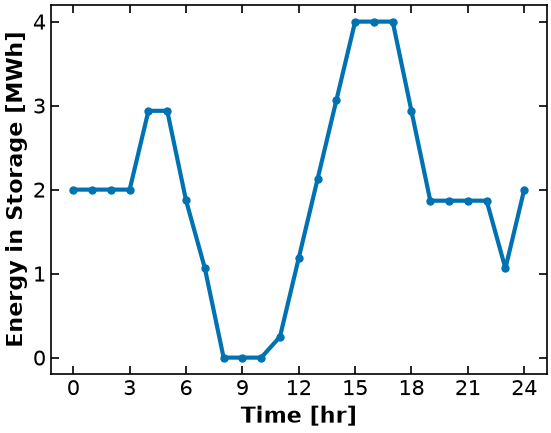

In [33]:
# Plot the state of charge, E_t.
#
# This is NOT a stair plot: energy is the integral of power, so E_t is
# piecewise linear in time. The graph below is the right shape.
plt.figure()

# Prepend t = 0 and E_0 so the trajectory starts at the initial condition
t_with_t0 = [0] + t
E_with_E0 = [pyo.value(m.E0)] + E_control

plt.plot(t_with_t0, E_with_E0, color=BLUE, linestyle="-", marker="o", markersize=5)
plt.xlabel("Time [hr]")
plt.ylabel("Energy in Storage [MWh]")
plt.xticks(range(0, 25, 3))
plt.show()

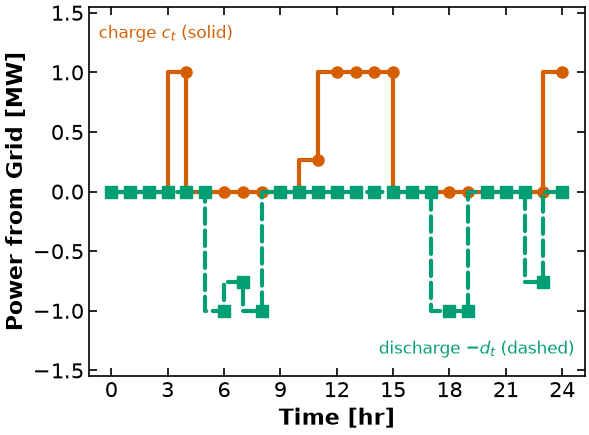

In [34]:
# Plot the charging and discharging rates.
plt.figure()

# Double up the first data point so the step plot has something to step from
c_with_t0 = [c_control[0]] + c_control
d_with_t0 = [d_control[0]] + d_control

# Three redundant channels per series -- colour, linestyle and marker.
# Vermillion and bluish green are only 3.5 L* apart, so they print as the same
# grey; solid-with-circles versus dashed-with-squares is what keeps them apart
# on a photocopy. See figures/README.md.
plt.step(t_with_t0, c_with_t0, where="pre", color=VERMILLION, linestyle="-", marker="o")
plt.step(
    t_with_t0, d_with_t0, where="pre", color=BLUISH_GREEN, linestyle="--", marker="s"
)

# Direct labelling in place of a legend: the house style prefers it, because a
# legend keyed only by colour is the usual way a figure dies in black and white.
plt.annotate(
    "charge $c_t$ (solid)",
    xy=(0.02, 0.95),
    xycoords="axes fraction",
    color=VERMILLION,
    fontsize=12,
    ha="left",
    va="top",
)
plt.annotate(
    "discharge $-d_t$ (dashed)",
    xy=(0.98, 0.05),
    xycoords="axes fraction",
    color=BLUISH_GREEN,
    fontsize=12,
    ha="right",
    va="bottom",
)

# Headroom top and bottom so the two direct labels clear the traces --
# set by looking at the rendered figure, not guessed.
plt.ylim(-1.55, 1.55)
plt.xlabel("Time [hr]")
plt.ylabel("Power from Grid [MW]")
plt.xticks(range(0, 25, 3))
plt.show()

### Accessing Dual Variables

In [35]:
### Declare all suffixes
# https://pyomo.readthedocs.io/en/stable/pyomo_modeling_components/Suffixes.html#exporting-suffix-data

# Ipopt bound multipliers
m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)

# Ipopt constraint multipliers
m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT_EXPORT)

# Resolve the model
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

Ipopt 3.14.19: max_iter=50


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       96
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       72
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       72
                     variables with only upper bounds:        0
Total number of equality constraints.................:       25


In [36]:
# Inspect dual variables for lower bound
m.ipopt_zL_out.display()

ipopt_zL_out : Direction=IMPORT, Datatype=FLOAT
    Key   : Value
    E[10] :      -0.794241619316072
    E[11] :  -9.959159559145174e-09
    E[12] :  -2.102627169661387e-09
    E[13] :  -1.175782908727664e-09
    E[14] :  -8.162117659813141e-10
    E[15] :    -6.2506885965562e-10
    E[16] :  -6.264563243789251e-10
    E[17] :  -6.263268931807182e-10
    E[18] :  -8.539379352204578e-10
    E[19] :  -1.341422206806913e-09
     E[1] : -1.2527829785585504e-09
    E[20] :  -1.341350289904925e-09
    E[21] : -1.3409814411365547e-09
    E[22] : -1.3409540074980453e-09
    E[23] : -2.3608437770291847e-09
    E[24] : -1.2529517735752844e-09
     E[2] : -1.2561427947619423e-09
     E[3] : -1.2655652532929373e-09
     E[4] :  -8.577658488886522e-10
     E[5] :  -8.581114250870307e-10
     E[6] : -1.3533628470961722e-09
     E[7] : -2.3510746270035887e-09
     E[8] :     -1.2933647690071222
     E[9] :     -3.0593573861032906
    c[10] :     -0.7539353271121387
    c[11] :  -9.178573911933398e-0

In [37]:
# Inspect dual variables for upper bound
m.ipopt_zU_out.display()

ipopt_zU_out : Direction=IMPORT, Datatype=FLOAT
    Key   : Value
    E[10] :  6.262126510435488e-10
    E[11] :  6.693766261750669e-10
    E[12] :    8.9355974571478e-10
    E[13] : 1.3437267429111052e-09
    E[14] :  2.713588361024654e-09
    E[15] :    0.14094426689949266
    E[16] :      10.74974729064419
    E[17] :      1.336923856231947
    E[18] :  2.351928363328083e-09
    E[19] : 1.1754291485433243e-09
     E[1] :  1.253120766471938e-09
    E[20] :  1.175503900129797e-09
    E[21] : 1.1758414697720055e-09
    E[22] : 1.1758669537676752e-09
    E[23] :   8.52768230140698e-10
    E[24] : 1.2529517547809998e-09
     E[2] : 1.2502665613514982e-09
     E[3] :   1.24632281279438e-09
     E[4] : 2.3442194466299494e-09
     E[5] : 2.3435146974157423e-09
     E[6] : 1.1716539589773153e-09
     E[7] :  8.540487163434175e-10
     E[8] :  6.263114689358477e-10
     E[9] :  6.264067093301249e-10
    c[10] :  2.501551046300082e-09
    c[11] :  3.485865653996596e-09
    c[12] :      2.66099

In [38]:
# Inspect duals for constraints
m.dual.display()

dual : Direction=IMPORT_EXPORT, Datatype=FLOAT
    Key                       : Value
        EnergyBalance_Con[10] : 32.449217973520675
        EnergyBalance_Con[11] :  31.65497635483081
        EnergyBalance_Con[12] :  31.65497634554103
        EnergyBalance_Con[13] : 31.654976344331963
        EnergyBalance_Con[14] : 31.654976344499907
        EnergyBalance_Con[15] : 31.654976346397284
        EnergyBalance_Con[16] : 31.795920612671708
        EnergyBalance_Con[17] :  42.54566790268944
        EnergyBalance_Con[18] : 43.882591758295064
        EnergyBalance_Con[19] :  43.88259175979305
         EnergyBalance_Con[1] : 36.801940126110026
        EnergyBalance_Con[20] :  43.88259175962706
        EnergyBalance_Con[21] : 43.882591759461214
        EnergyBalance_Con[22] :  43.88259175929607
        EnergyBalance_Con[23] :  43.88259175913098
        EnergyBalance_Con[24] :  43.88259175762291
         EnergyBalance_Con[2] :  36.80194012611037
         EnergyBalance_Con[3] :  36.801940126104

## Try Another Solver

Let's see how easy it is to switch to another solver with Pyomo.

<div class="admonition note"> 
<p class="title"><b>Activity</b></p>
 Create a new instance of <tt>SolverFactory</tt> by specifying <tt>'cbc'</tt> or <tt>'appsi_highs'</tt> as the solver name. Then solve the Pyomo model <tt>m</tt> and store the results in <tt>results2</tt>.
</div>

In [ ]:
# Specify another solver
# Add your solution here

# Regenerate model without suffixes
# Note: CBC does not have the same suffix interface as Ipopt to get the dual variables
m = build_model(price=ca_data["price"][24:48].to_numpy(), e0=0)

# Resolve the model
results2 = solver2.solve(m, tee=True)
assert pyo.check_optimal_termination(results2), (
    f"Solve failed: status={results2.solver.status}, "
    f"termination={results2.solver.termination_condition}"
)

Notice we used `solver2`, which is an instance of `SolverFactory` for the solver `cbc`. But we rebuilt model `m` with `build_model` first, because `cbc` does not support the Ipopt suffixes declared above. This means `cbc` started from the default initial values, not from the solution found by `ipopt`.

## Battery Arbitrage Under Uncertainty

Everything above assumed we knew the prices. We do not. The day-ahead market
requires a **bid** --- a commitment for the first period --- submitted before the
prices are known; everything after that can react to what actually happened.

That is a **two-stage stochastic program**:

* **First stage, "here and now".** The committed first-period schedule
  $\hat{c}, \hat{d}$. One decision, made once, before anything is revealed.
* **Second stage, "wait and see".** Everything after the first period. It may
  differ from scenario to scenario, because by then we know which scenario we
  are in.

**New set.** $\mathcal{S}$, the price scenarios, with probabilities $\pi_s$
summing to one and prices $p_{t,s}$.

$$
\begin{align*}
\max \quad & \sum_{s \in \mathcal{S}} \pi_s \sum_{t \in \mathcal{T}} p_{t,s}\,(d_{t,s} - c_{t,s})\,\Delta t
  && \text{expected profit [\$]} \\
\text{s.t.} \quad
  & E_{t,s} = E_{t-1,s} + \Big( c_{t,s}\sqrt{\eta} - \frac{d_{t,s}}{\sqrt{\eta}} \Big) \Delta t
  && \forall\, t \in \mathcal{T}, \; s \in \mathcal{S} \\
  & E_{N,s} = E_0 && \forall\, s \in \mathcal{S} \\
  & c_{1,s} = \hat{c}, \quad d_{1,s} = \hat{d} && \forall\, s \in \mathcal{S} \\
  & \text{bounds as before, for all } t, s
\end{align*}
$$

The third block is the only genuinely new idea: **non-anticipativity**. It says
the commitment cannot depend on which scenario turns out to be true. Without it
the problem falls apart into $|\mathcal{S}|$ separate hindsight problems, each
of which knows the future.

Nothing changed *in kind*: this is still a linear program, every row the same
row replicated. What changed is a factor of $|\mathcal{S}|$ on every count.


### Building scenarios from the CAISO data

We have a full year of hourly prices for one California node. Take
$|\mathcal{T}| = 1$ week ($168$ hours) and sample $|\mathcal{S}| = 20$ distinct
weeks from the year, each equally likely. That is a crude but honest scenario
set: every scenario is a week of prices that actually happened.

**Seed the sampler.** An unseeded scenario set gives a different answer, and a
different figure, every time the notebook runs.


In [40]:
# Scenario construction. SEEDED, so this reproduces.
SEED = 0
HOURS_PER_WEEK = 168
N_SCENARIOS = 20

rng = np.random.default_rng(SEED)

prices_year = ca_data["price"].to_numpy()
n_weeks = len(prices_year) // HOURS_PER_WEEK

# Sample 20 distinct weeks from the year, without replacement
weeks = np.sort(rng.choice(n_weeks, size=N_SCENARIOS, replace=False))

# price_scenarios[s, t] = price in hour t of the s-th sampled week [USD/MWh]
price_scenarios = np.array(
    [prices_year[w * HOURS_PER_WEEK : (w + 1) * HOURS_PER_WEEK] for w in weeks]
)

print(f"{len(prices_year)} hourly prices, {n_weeks} whole weeks in the year")
print(f"Sampled weeks (0-indexed): {weeks}")
print(f"price_scenarios has shape {price_scenarios.shape}  = (|S|, |T|)")

8760 hourly prices, 52 whole weeks in the year
Sampled weeks (0-indexed): [ 0  1  2  7  9 11 17 21 22 27 28 30 34 35 40 45 46 48 49 50]
price_scenarios has shape (20, 168)  = (|S|, |T|)


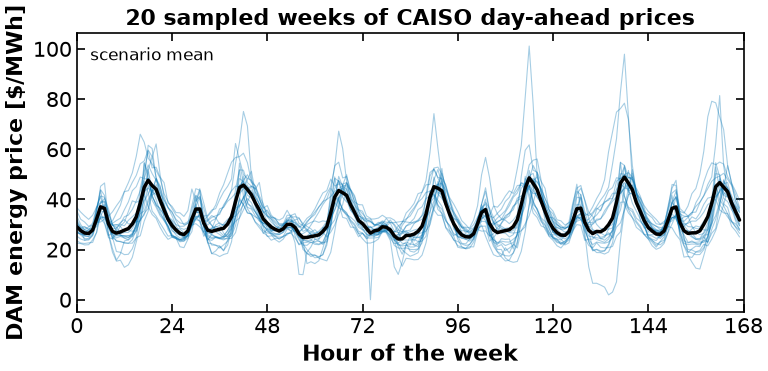

In [41]:
# The ensemble of price forecasts.
#
# A wide figure, set explicitly: the x axis is 168 hours long, and the house
# default 6.4 x 4.8 squeezes a week into something unreadable. Per-figure
# aspect ratios are normal -- the scripts in figures/plots/ all set their own.
fig, ax = plt.subplots(figsize=(8.0, 4.0))

# All 20 scenarios in ONE colour, on purpose. They are a cloud, not 20 series
# to tell apart; the only thing that has to stand out from them is their mean.
for s in range(N_SCENARIOS):
    ax.plot(price_scenarios[s], color=BLUE, linestyle="-", linewidth=0.8, alpha=0.35)

ax.plot(price_scenarios.mean(axis=0), color="black", linestyle="-", linewidth=2.5)
ax.annotate(
    "scenario mean",
    xy=(0.02, 0.95),
    xycoords="axes fraction",
    color="black",
    fontsize=12,
    ha="left",
    va="top",
)

ax.set_xlabel("Hour of the week")
ax.set_ylabel("DAM energy price [$/MWh]")
ax.set_title(f"{N_SCENARIOS} sampled weeks of CAISO day-ahead prices")
ax.set_xticks(range(0, 169, 24))
ax.set_xlim(0, 168)
plt.tight_layout()
plt.show()

### The Pyomo model

One implementation choice is worth stating out loud, because there are two
reasonable ways to do this in Pyomo.

* **A set over scenarios, and an extra index on every variable.** That is what
  the code below does. `m.SCENARIOS` is an ordinary `pyo.Set`, and `m.c` becomes
  `m.c[s, t]` instead of `m.c[t]`. The model reads as "the same model,
  replicated $|\mathcal{S}|$ times, plus the non-anticipativity rows".
* **A `pyo.Block` per scenario**, which packages one scenario's variables and
  constraints into a reusable sub-model. That is the right tool when you want to
  *exploit* the block structure --- which is exactly what decomposition
  algorithms do.

We use the first here, because the point right now is that a stochastic program
is just a bigger version of the same LP. Blocks come in the stochastic
programming lectures, where the structure is the point.


In [42]:
def build_stochastic_model(price_scenarios, e0=0.0, prob=None, n_commit=1):
    """Two-stage stochastic battery arbitrage model

    First stage (here and now): the charge/discharge schedule for the FIRST
    hour, committed before tomorrow's prices are known.
    Second stage (wait and see): everything after that may react to whichever
    price scenario turned out to be true.

    Arguments (inputs):
        price_scenarios: 2D NumPy array, shape (|S|, |T|), of prices [USD/MWh]
        e0: initial and final energy storage level [MWh]
        prob: 1D array of scenario probabilities; equally likely if None

    Returns (outputs):
        m: Pyomo optimization model

    Implementation note: the scenarios are carried by an ordinary pyo.Set and
    an extra index on every variable. That is deliberate. Pyomo also offers
    Block, which packages one scenario's variables and constraints into a
    reusable sub-model; we use Blocks in the stochastic programming lectures,
    where the block structure is the whole point. Here the extra index makes
    the "same model, replicated |S| times" reading as plain as possible.
    """
    n_scen, n_time = price_scenarios.shape

    if prob is None:
        prob = np.ones(n_scen) / n_scen
    assert abs(sum(prob) - 1.0) < 1e-10, "Scenario probabilities must sum to 1"

    m = pyo.ConcreteModel("Two-stage battery arbitrage")

    ## Sets

    # Time periods, T in the notes
    m.HORIZON = pyo.Set(initialize=range(n_time))

    # Price scenarios, S in the notes
    m.SCENARIOS = pyo.Set(initialize=range(n_scen))

    ## Parameters

    # Probability of scenario s, pi_s [dimensionless]
    m.prob = pyo.Param(m.SCENARIOS, initialize=dict(enumerate(prob)))

    # Price in period t under scenario s, p_{t,s} [USD/MWh]
    m.price = pyo.Param(
        m.SCENARIOS,
        m.HORIZON,
        initialize={
            (s, t): float(price_scenarios[s, t])
            for s in range(n_scen)
            for t in range(n_time)
        },
        units=u.USD / u.MWh,
    )

    # Square root of round trip efficiency [dimensionless]
    m.sqrteta = pyo.Param(initialize=pyo.sqrt(0.88))

    # Energy in battery at t = 0 [MWh]
    m.E0 = pyo.Param(initialize=e0, mutable=True, units=u.MWh)

    # Timestep [hr]
    m.dt = pyo.Param(initialize=1.0, units=u.hr)

    ## Variables

    # SECOND STAGE. Charging rate in period t under scenario s [MW]
    m.c = pyo.Var(m.SCENARIOS, m.HORIZON, bounds=(0, 1), initialize=0.0, units=u.MW)

    # SECOND STAGE. Discharging rate in period t under scenario s [MW]
    m.d = pyo.Var(m.SCENARIOS, m.HORIZON, bounds=(0, 1), initialize=0.0, units=u.MW)

    # SECOND STAGE. Energy stored at the end of period t under scenario s [MWh]
    m.E = pyo.Var(m.SCENARIOS, m.HORIZON, bounds=(0, 4), initialize=0.0, units=u.MWh)

    # FIRST STAGE. The committed first-period schedule, chosen before the
    # scenario is revealed. These are the here-and-now decisions.
    m.COMMIT = pyo.Set(initialize=range(n_commit))
    m.c_hat = pyo.Var(m.COMMIT, bounds=(0, 1), initialize=0.0, units=u.MW)
    m.d_hat = pyo.Var(m.COMMIT, bounds=(0, 1), initialize=0.0, units=u.MW)

    ## Constraints

    # Energy balance, one row per (scenario, period). [MWh] = [MWh] + [hr]*[MW]
    @m.Constraint(m.SCENARIOS, m.HORIZON)
    def EnergyBalance_Con(b, s, t):
        previous = b.E0 if t == 0 else b.E[s, t - 1]
        return b.E[s, t] == previous + b.dt * (
            b.c[s, t] * b.sqrteta - b.d[s, t] / b.sqrteta
        )

    # Periodic boundary: end each scenario where we started [MWh]
    @m.Constraint(m.SCENARIOS)
    def PeriodicBoundaryCondition(b, s):
        return b.E[s, n_time - 1] == b.E0

    # NON-ANTICIPATIVITY. The first-period commitment cannot depend on which
    # scenario turns out to be true. This is the only genuinely new idea. [MW]
    @m.Constraint(m.SCENARIOS, m.COMMIT)
    def NonAnticipativity_c(b, s, t):
        return b.c[s, t] == b.c_hat[t]

    @m.Constraint(m.SCENARIOS, m.COMMIT)
    def NonAnticipativity_d(b, s, t):
        return b.d[s, t] == b.d_hat[t]

    ## Objective: expected profit [USD]
    @m.Objective(sense=pyo.maximize)
    def OBJ(b):
        return sum(
            b.prob[s]
            * sum(b.price[s, t] * (b.d[s, t] - b.c[s, t]) * b.dt for t in b.HORIZON)
            for s in b.SCENARIOS
        )

    # Raises UnitsError if any constraint or the objective is inconsistent
    assert_units_consistent(m)

    return m

### Solve it

The model has $3|\mathcal{T}||\mathcal{S}| + 2$ continuous variables and
$(|\mathcal{T}| + 3)|\mathcal{S}|$ linear equality constraints: $|\mathcal{T}|$
energy balances, one periodic condition and two non-anticipativity rows, per
scenario. Let us check that against what Pyomo actually built.


In [43]:
m_stoch = build_stochastic_model(price_scenarios, e0=0.0)

n_var = sum(1 for _ in m_stoch.component_data_objects(pyo.Var))
n_con = sum(1 for _ in m_stoch.component_data_objects(pyo.Constraint))

T = len(m_stoch.HORIZON)
S = len(m_stoch.SCENARIOS)
print(f"|T| = {T}, |S| = {S}")
print(f"continuous variables:  {n_var:>6}   3|T||S| + 2      = {3 * T * S + 2:>6}")
print(f"equality constraints:  {n_con:>6}   (|T| + 3)|S|     = {(T + 3) * S:>6}")

assert n_var == 3 * T * S + 2
assert n_con == (T + 3) * S

lp_solver = pyo.SolverFactory("cbc")
results = lp_solver.solve(m_stoch)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print(f"\nExpected profit over the {S} scenarios = ${pyo.value(m_stoch.OBJ):,.2f}")
print(
    f"Here-and-now commitment: c_hat = {pyo.value(m_stoch.c_hat[0]):.4f} MW, "
    f"d_hat = {pyo.value(m_stoch.d_hat[0]):.4f} MW"
)

|T| = 168, |S| = 20
continuous variables:   10082   3|T||S| + 2      =  10082
equality constraints:    3420   (|T| + 3)|S|     =   3420



Expected profit over the 20 scenarios = $554.28
Here-and-now commitment: c_hat = 0.0000 MW, d_hat = 0.0000 MW


### What did non-anticipativity cost?

Solve each scenario **on its own**. That is the same model with
$|\mathcal{S}| = 1$: a battery that knows in advance exactly which week it is
about to see. Averaging those $20$ profits gives the **perfect-foresight**
value, which no stochastic solution can beat.

The interesting column is not the profit. It is the first-hour decision each
hindsight problem would have made.


In [44]:
rows = []
for s in range(N_SCENARIOS):
    m_s = build_stochastic_model(price_scenarios[s : s + 1], e0=0.0)
    res_s = lp_solver.solve(m_s)
    assert pyo.check_optimal_termination(res_s), f"Solve failed for scenario {s}"
    rows.append(
        {
            "week": int(weeks[s]),
            "hour-0 price": price_scenarios[s, 0],
            "perfect-foresight profit": pyo.value(m_s.OBJ),
            "would charge in hour 0": pyo.value(m_s.c_hat[0]),
        }
    )

wait_and_see = pd.DataFrame(rows)
display(wait_and_see.round(4))

pf = wait_and_see["perfect-foresight profit"].mean()
sp = pyo.value(m_stoch.OBJ)
print(f"Average perfect-foresight profit : ${pf:,.2f}")
print(f"Two-stage stochastic profit      : ${sp:,.2f}")
print(
    f"Cost of not knowing              : ${pf - sp:,.2f}  ({100 * (pf - sp) / pf:.2f}%)"
)

,week,hour-0 price,perfect-foresight profit,would charge in hour 0
0,0,36.757,686.6153,0.0000
1,1,28.847,526.5741,0.0000
2,2,28.454,537.0852,0.2640
3,7,27.108,514.4652,0.0000
4,9,26.773,605.4655,1.0000
5,11,22.553,719.8800,1.0000
6,17,29.781,597.9438,0.0000
7,21,25.401,517.1913,1.0000
8,22,27.484,428.9913,0.0000
9,27,31.125,379.2313,0.0000


Average perfect-foresight profit : $554.53
Two-stage stochastic profit      : $554.28
Cost of not knowing              : $0.25  (0.05%)


Read the last column. Several of the twenty weeks, *knowing* what was coming,
would have charged at the full rate in hour 0; most would have done nothing; a
couple would have charged partially. The here-and-now decision has to be **one
number** for all twenty, and it comes out as the value no single scenario would
have picked if it knew.

The gap is small here, and that is worth saying rather than hiding: when only
the first of $168$ hours is committed, there is a whole week left in which to
recover from a bad bid. The commitment has to bite before uncertainty costs
real money.


### Make the commitment bite: bid the whole first day

A real day-ahead bid is not one hour, it is twenty-four. `build_stochastic_model`
takes `n_commit` for exactly this: the first `n_commit` periods are here-and-now
and shared across all scenarios, and the rest are wait-and-see. Setting
`n_commit=1` is the model written above; setting `n_commit=24` commits the first
day.


In [45]:
m_day = build_stochastic_model(price_scenarios, e0=0.0, n_commit=24)
res_day = lp_solver.solve(m_day)
assert pyo.check_optimal_termination(res_day), "Solve failed"

sp_day = pyo.value(m_day.OBJ)
print(
    f"Commit 1 hour  : ${sp:,.2f}   ({100 * (pf - sp) / pf:.2f}% below perfect foresight)"
)
print(
    f"Commit 24 hours: ${sp_day:,.2f}   ({100 * (pf - sp_day) / pf:.2f}% below perfect foresight)"
)

Commit 1 hour  : $554.28   (0.05% below perfect foresight)
Commit 24 hours: $540.97   (2.45% below perfect foresight)


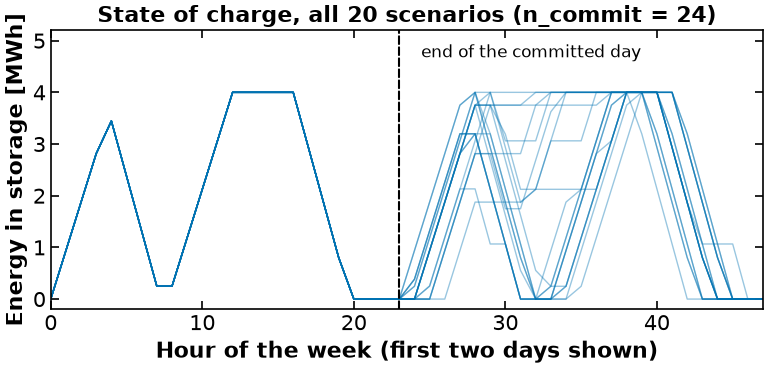

In [46]:
# Non-anticipativity, made visible: the committed day is one trajectory, and
# the scenarios only separate once the commitment ends. One colour for the
# whole ensemble again -- the message is WHERE they diverge, not which is which.
HOURS_SHOWN = 48

fig, ax = plt.subplots(figsize=(8.0, 4.0))
for s in m_day.SCENARIOS:
    ax.plot(
        [pyo.value(m_day.E[s, t]) for t in range(HOURS_SHOWN)],
        color=BLUE,
        linestyle="-",
        linewidth=1.0,
        alpha=0.4,
    )

# The commitment boundary is an annotation, not a series, so it is black and
# labelled in place. Nothing in this figure is keyed by hue.
ax.axvline(23, color="black", linestyle="--", linewidth=1.5)
ax.annotate(
    "end of the committed day",
    xy=(0.52, 0.95),
    xycoords="axes fraction",
    color="black",
    fontsize=12,
    ha="left",
    va="top",
)

ax.set_xlabel("Hour of the week (first two days shown)")
ax.set_ylabel("Energy in storage [MWh]")
ax.set_title(f"State of charge, all {N_SCENARIOS} scenarios (n_commit = 24)")
ax.set_xlim(0, HOURS_SHOWN - 1)
ax.set_ylim(-0.2, 5.2)  # headroom for the boundary label
plt.tight_layout()
plt.show()

<div class="admonition note">
<p class="title"><b>Activity</b></p>
 Change <tt>SEED</tt> and re-run. How much does the expected
profit move? How much does the here-and-now commitment move? Then change
<tt>N_SCENARIOS</tt> from 20 to 5 and to 50: which of those two numbers is
sensitive to the size of the scenario set, and which is not?
</div>


**Take away messages for the stochastic model**

* A two-stage stochastic program is the *same* LP, replicated once per scenario,
  plus non-anticipativity rows that tie the here-and-now decisions together.
  $3|\mathcal{T}||\mathcal{S}| + 2$ variables here --- and that factor of
  $|\mathcal{S}|$ is the entire difficulty of the field.
* **Non-anticipativity is the modeling idea, not the size.** Drop it and you have
  not solved a harder problem; you have solved twenty easier ones that all cheat.
* The scenario set is data, and it was *sampled*. Seed the sampler and report the
  seed, or the number you print is not reproducible.


## References

This notebook is based on Chapter 4 of Bynum, M. L., Hackebeil, G. A., Hart, W. E., Laird, C. D.,
Nicholson, B. L., Siirola, J. D., Watson, J.-P., & Woodruff, D. L. (2021). *Pyomo — Optimization
Modeling in Python*, 3rd ed. (Vol. 67). Cham: Springer.
<https://doi.org/10.1007/978-3-030-68928-5>

The keyword-argument tables above are **not** taken from that book. They are compiled from the
[Pyomo documentation](https://pyomo.readthedocs.io/en/stable/), which is BSD-licensed, and every
row was checked against the installed Pyomo (6.10.1) — Pyomo has moved since the 3rd edition, and
the tables note where it has.
